In [1]:
# Re-import required libraries after execution state reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.stats import entropy

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer()
vectorizer.fit(train["review"])
X_train = vectorizer.transform(train["review"])
X_pool = vectorizer.transform(test["review"])
y_train = train['sentiment']

# Train an initial logistic regression model
model = LogisticRegression()
model.fit(X_train, train['sentiment'])

LogisticRegression()

In [4]:
# Predict probabilities on the unlabeled pool
probs = model.predict_proba(X_pool)

# Compute entropy for each prediction
entropies = entropy(probs.T)  # Transpose to match expected format

entropy_df = pd.DataFrame({"review": test["review"], "probs" : probs[:, 1], "entropy": entropies})
entropy_df.to_csv("entropy_1.csv", index = False)

# Second Iteration

By manually labelling top 20 accounts sorted by high entropy and pasting them into 50 train data, remove from the entropy_1 file and name it test_2

In [5]:
train = pd.read_csv("train_2.csv")
test = pd.read_csv("test_2.csv")

In [6]:
# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer()
vectorizer.fit(train["review"])
X_train = vectorizer.transform(train["review"])
X_pool = vectorizer.transform(test["review"])
y_train = train['sentiment']

# Train an initial logistic regression model
model = LogisticRegression()
model.fit(X_train, train['sentiment'])

LogisticRegression()

In [7]:
# Predict probabilities on the unlabeled pool
probs = model.predict_proba(X_pool)

# Compute entropy for each prediction
entropies = entropy(probs.T)  # Transpose to match expected format

entropy_df = pd.DataFrame({"review": test["review"], "probs" : probs[:, 1], "entropy": entropies})
entropy_df.to_csv("entropy_2.csv", index = False)

# Third iterition

In [8]:
train = pd.read_csv("train_3.csv")
test = pd.read_csv("test_3.csv")

In [9]:
# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer()
vectorizer.fit(train["review"])
X_train = vectorizer.transform(train["review"])
X_pool = vectorizer.transform(test["review"])
y_train = train['sentiment']

# Train an initial logistic regression model
model = LogisticRegression()
model.fit(X_train, train['sentiment'])

LogisticRegression()

In [10]:
# Predict probabilities on the unlabeled pool
probs = model.predict_proba(X_pool)

# Compute entropy for each prediction
entropies = entropy(probs.T)  # Transpose to match expected format

entropy_df = pd.DataFrame({"review": test["review"], "probs" : probs[:, 1], "entropy": entropies})
entropy_df.to_csv("entropy_3.csv", index = False)

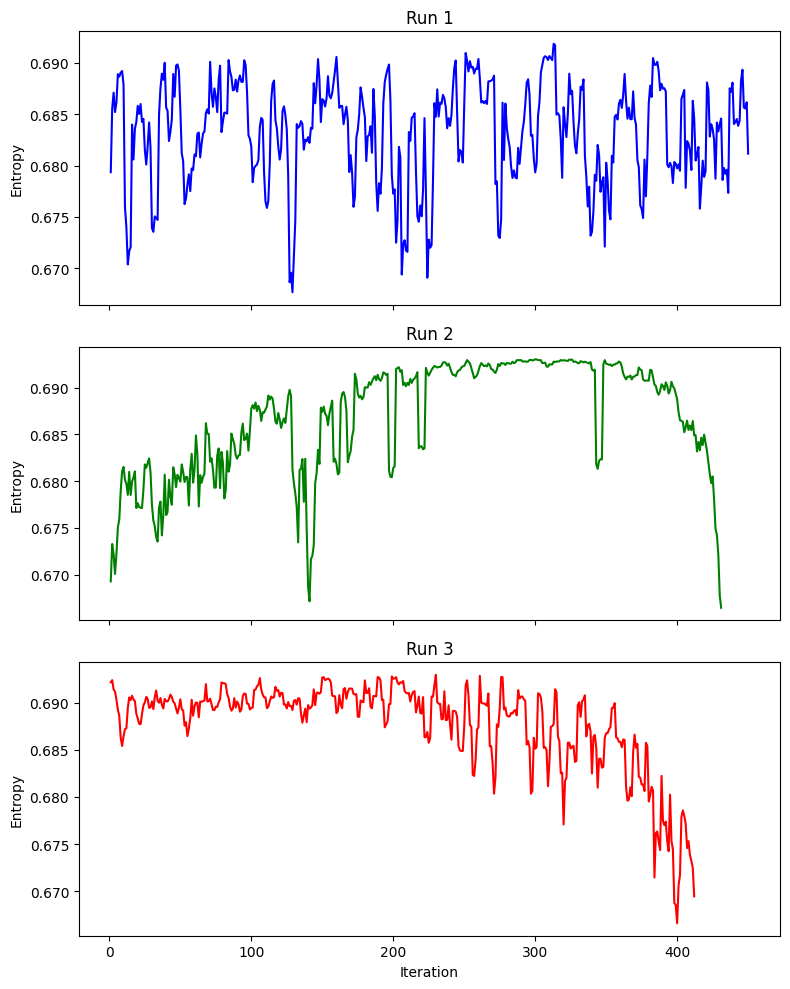

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
entropy_1 = pd.read_csv("entropy_1.csv")
entropy_2 = pd.read_csv("entropy_2.csv")
entropy_3 = pd.read_csv("entropy_3.csv")

# Apply rolling average for smoothing (window size = 5)
window_size = 5
entropy_1["smoothed"] = entropy_1["entropy"].rolling(window=window_size, min_periods=1).mean()
entropy_2["smoothed"] = entropy_2["entropy"].rolling(window=window_size, min_periods=1).mean()
entropy_3["smoothed"] = entropy_3["entropy"].rolling(window=window_size, min_periods=1).mean()

# Set up subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Plot separately
sns.lineplot(x=range(1, len(entropy_1) + 1), y=entropy_1["smoothed"], ax=axes[0], color='b')
axes[0].set_title("Run 1")
axes[0].set_ylabel("Entropy")

sns.lineplot(x=range(1, len(entropy_2) + 1), y=entropy_2["smoothed"], ax=axes[1], color='g')
axes[1].set_title("Run 2")
axes[1].set_ylabel("Entropy")

sns.lineplot(x=range(1, len(entropy_3) + 1), y=entropy_3["smoothed"], ax=axes[2], color='r')
axes[2].set_title("Run 3")
axes[2].set_ylabel("Entropy")
axes[2].set_xlabel("Iteration")

# Adjust layout
plt.tight_layout()
plt.show()


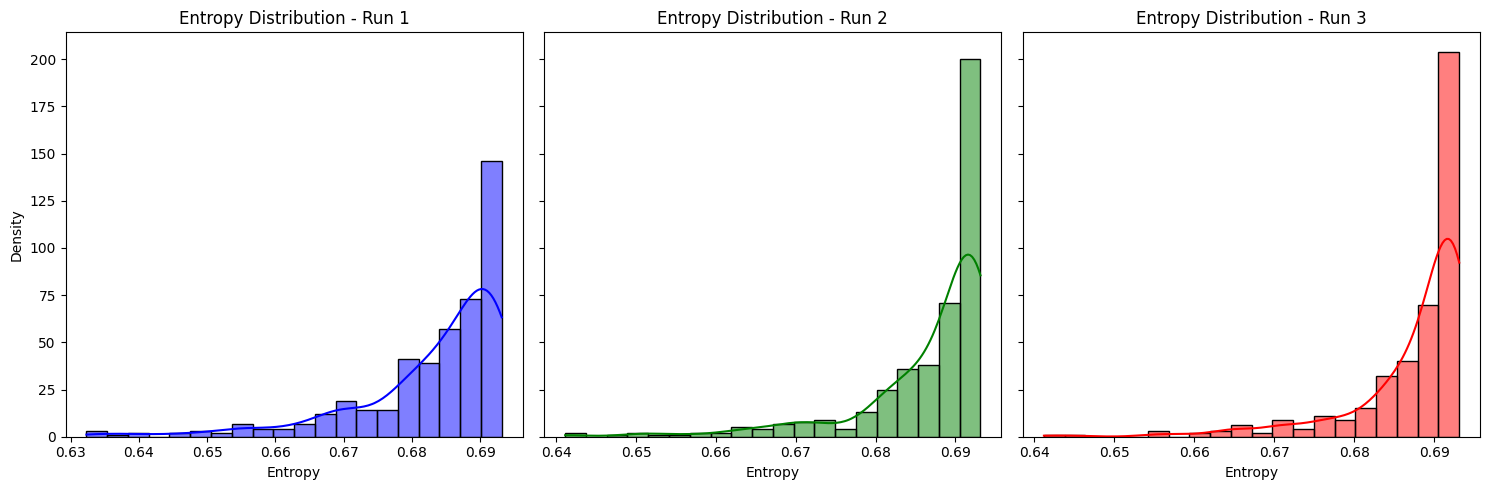

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
entropy_1 = pd.read_csv("entropy_1.csv")
entropy_2 = pd.read_csv("entropy_2.csv")
entropy_3 = pd.read_csv("entropy_3.csv")

# Set up subplots for distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Plot histogram + KDE for each entropy run
sns.histplot(entropy_1["entropy"], kde=True, bins=20, ax=axes[0], color='b')
axes[0].set_title("Entropy Distribution - Run 1")
axes[0].set_xlabel("Entropy")
axes[0].set_ylabel("Density")

sns.histplot(entropy_2["entropy"], kde=True, bins=20, ax=axes[1], color='g')
axes[1].set_title("Entropy Distribution - Run 2")
axes[1].set_xlabel("Entropy")

sns.histplot(entropy_3["entropy"], kde=True, bins=20, ax=axes[2], color='r')
axes[2].set_title("Entropy Distribution - Run 3")
axes[2].set_xlabel("Entropy")

# Adjust layout
plt.tight_layout()
plt.show()


# Iteration 4

In [15]:
train = pd.read_csv("train_4.csv")
test = pd.read_csv("test_4.csv")

In [16]:
# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer()
vectorizer.fit(train["review"])
X_train = vectorizer.transform(train["review"])
X_pool = vectorizer.transform(test["review"])
y_train = train['sentiment']

# Train an initial logistic regression model
model = LogisticRegression()
model.fit(X_train, train['sentiment'])

LogisticRegression()

In [17]:
# Predict probabilities on the unlabeled pool
probs = model.predict_proba(X_pool)

# Compute entropy for each prediction
entropies = entropy(probs.T)  # Transpose to match expected format

entropy_df = pd.DataFrame({"review": test["review"], "probs" : probs[:, 1], "entropy": entropies})
entropy_df.to_csv("entropy_4.csv", index = False)

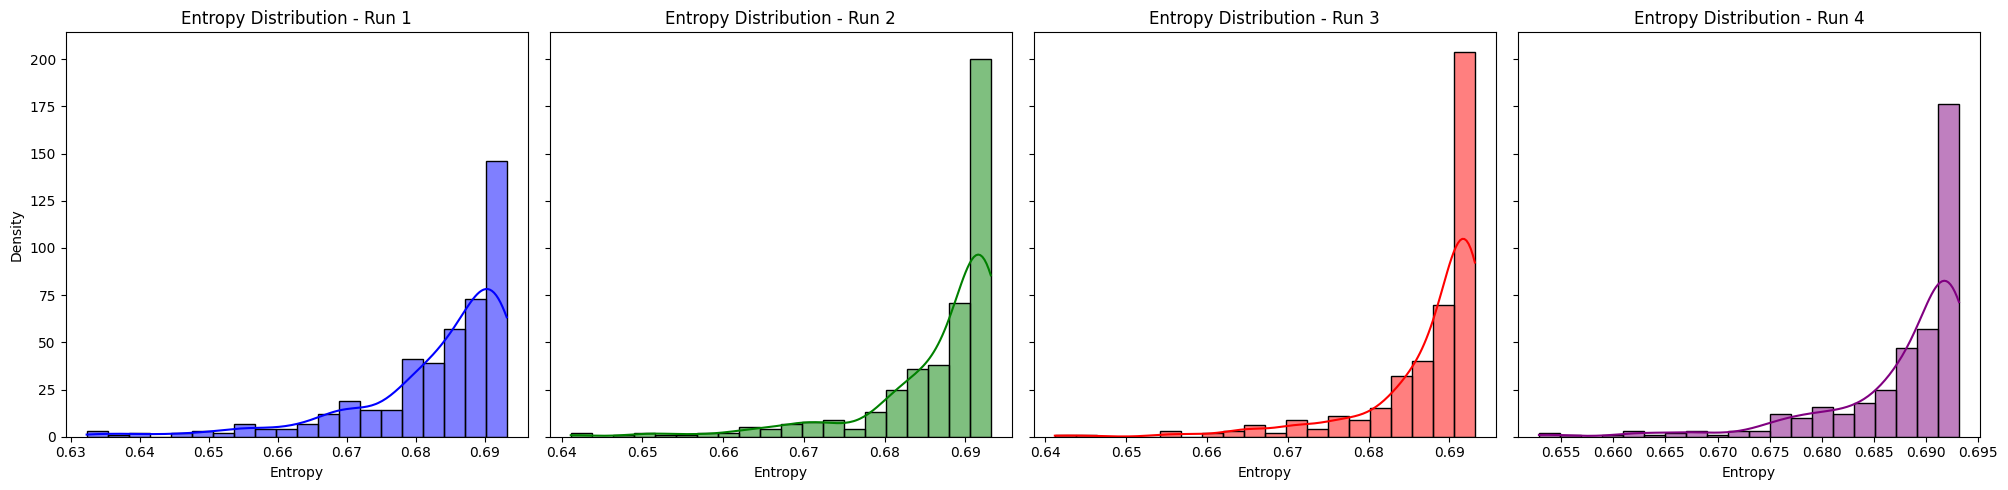

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load entropy data from CSV files
entropy_1 = pd.read_csv("entropy_1.csv")["entropy"]
entropy_2 = pd.read_csv("entropy_2.csv")["entropy"]
entropy_3 = pd.read_csv("entropy_3.csv")["entropy"]
entropy_4 = pd.read_csv("entropy_4.csv")["entropy"]

# Set up subplots (1 row, 4 columns)
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

# Plot histogram + KDE for each entropy run
sns.histplot(entropy_1, kde=True, bins=20, ax=axes[0], color='b')
axes[0].set_title("Entropy Distribution - Run 1")
axes[0].set_xlabel("Entropy")
axes[0].set_ylabel("Density")

sns.histplot(entropy_2, kde=True, bins=20, ax=axes[1], color='g')
axes[1].set_title("Entropy Distribution - Run 2")
axes[1].set_xlabel("Entropy")

sns.histplot(entropy_3, kde=True, bins=20, ax=axes[2], color='r')
axes[2].set_title("Entropy Distribution - Run 3")
axes[2].set_xlabel("Entropy")

sns.histplot(entropy_4, kde=True, bins=20, ax=axes[3], color='purple')
axes[3].set_title("Entropy Distribution - Run 4")
axes[3].set_xlabel("Entropy")

# Adjust layout
plt.tight_layout()
plt.show()


<ipython-input-23-e1ffa0015c9f>:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Iterations", title_fontsize=13, fontsize=12, loc="upper right")


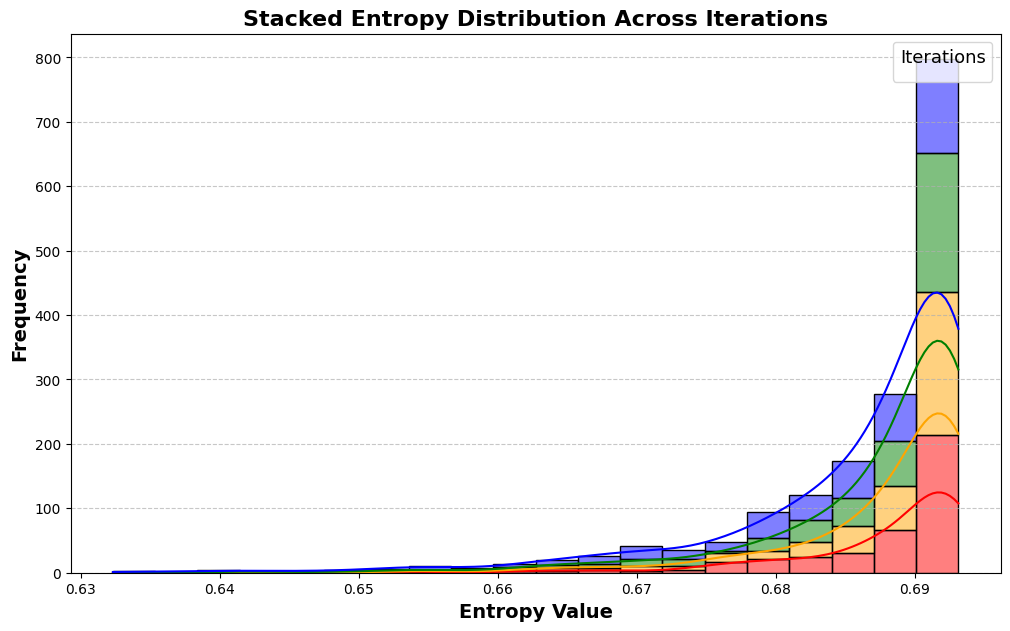

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load entropy data from CSV files
entropy_1 = pd.read_csv("entropy_1.csv")["entropy"]
entropy_2 = pd.read_csv("entropy_2.csv")["entropy"]
entropy_3 = pd.read_csv("entropy_3.csv")["entropy"]
entropy_4 = pd.read_csv("entropy_4.csv")["entropy"]

# Combine all entropy values into a single DataFrame
entropy_data = pd.DataFrame({
    "Entropy": pd.concat([entropy_1, entropy_2, entropy_3, entropy_4], ignore_index=True),
    "Iteration": (["Iteration 1"] * len(entropy_1)) +
                 (["Iteration 2"] * len(entropy_2)) +
                 (["Iteration 3"] * len(entropy_3)) +
                 (["Iteration 4"] * len(entropy_4))
})

# Set figure size
plt.figure(figsize=(12, 7))

# Plot stacked histogram with KDE
sns.histplot(data=entropy_data, x="Entropy", hue="Iteration", bins=20, kde=True, multiple="stack",
             palette=["blue", "green", "orange", "red"])

# Improve labels and title
plt.xlabel("Entropy Value", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title("Stacked Entropy Distribution Across Iterations", fontsize=16, fontweight='bold')

# Add legend with clear labels
plt.legend(title="Iterations", title_fontsize=13, fontsize=12, loc="upper right")

# Improve grid visibility
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()
